In [1]:
'''libraries'''
#Data
import pandas as pd

#Plots
import matplotlib.pyplot as plt

#math
import numpy as np

#Constants
from scipy.constants import physical_constants
m_u=physical_constants['atomic mass constant energy equivalent in MeV'][0]
from scipy.constants import speed_of_light as c

#Usefull
from tqdm.notebook import tqdm
import os
from scipy.interpolate import interp1d
import pynucastro as pyna
#%matplotlib widget

Read Data from the Snaps


In [2]:

input_rates_1=r'Nuclear_Data\Original_files\Reaclib_18_9_20'
folder_1 = r'Runs\Run_1\snaps'
input_rates_2=r'Nuclear_Data\Just_experimental\Reaclib_exp_R1'
folder_2=r'Runs\Run_2\snaps'
input_rates_3=r'Empirical_formulas\Beta_minus_empirical\Tian2025\Exp_Tian_beta_R1'
folder_3=r'Runs\Run_Tian\snaps'
input_rates_4=r'Empirical_formulas\Alpha_empirical\NMHF2021\Exp_Tian_NMHF_R1'
folder_4=r'Runs\Run_Tian_NMHF\snaps'
folder_4_3=r'Runs\Run_Tian_NMHF_3\snaps'
input_rates_5=r'Empirical_formulas\Alpha_empirical\SONG\Exp_Tian_SONG_R1'
folder_5=r'Runs\Run_Tian_SONG\snaps'
folder_5_3=r'Runs\Run_Tian_SONG_3\snaps'
input_rates_6=r'Empirical_formulas\Alpha_empirical\ROYER\Exp_Tian_royer_R1'
folder_6=r'Runs\Run_Tian_royer\snaps'
input_rates_10=r'Empirical_formulas\Alpha_empirical\NMHF2021\Exp_Zhou_NMHF_R1'
folder_10=r'Runs\Run_Zhou_NMHF\snaps'
folder_10_3=r'Runs\Run_Zhou_NMHF_3\snaps'
input_rates_11=r'Empirical_formulas\Alpha_empirical\SONG\Exp_Zhou_SONG_R1'
folder_11=r'Runs\Run_Zhou_SONG\snaps'
input_rates_12=r'Empirical_formulas\Alpha_empirical\ROYER\Exp_Zhou_royer_R1'
folder_12=r'Runs\Run_Zhou_royer\snaps'


input_masses=r'Nuclear_Data\Original_files\winvne_v2.0.dat'

input_rates=input_rates_1
folder=folder_1

files = os.listdir(folder)

abundances_winnet=[]
time_Winnet=[]


for file in tqdm(files):
    time_i=float(np.loadtxt(os.path.join(folder, file), skiprows=1,max_rows=1, usecols=0))
    if time_i>1:
        abundances_winnet.append(np.loadtxt(os.path.join(folder, file), skiprows=3))
        time_Winnet.append(float(np.loadtxt(os.path.join(folder, file), skiprows=1,max_rows=1, usecols=0)))

abundances_winnet = np.array(abundances_winnet)
time_Winnet = np.array(time_Winnet) 
nuclear_data=pd.read_csv(input_masses,skiprows=lambda x: not (x>7854 and (x-7855)%4==0),delim_whitespace=True,names=['name','A','Z','N','spin','Mass excess (Mev)','source'])


  0%|          | 0/5737 [00:00<?, ?it/s]

Interpolation to have a smooth Xi curve

In [3]:
initial_time=time_Winnet[0] #seconds
final_time=4.32E7 #seconds 500 days= 4.32E7 seconds 100 days= 8.64E7 seconds
N_steps=10000
time = np.exp(np.linspace(np.log(initial_time), np.log(final_time), N_steps))
abundances_time= np.empty((abundances_winnet.shape[1],N_steps))

for i in tqdm(range(abundances_winnet.shape[1])):
    spline_interp = interp1d(time_Winnet, abundances_winnet[:,i,3], kind='linear')
    abundances_time[i] = spline_interp(time)


def index_n_z(n,z):
    idx_start = np.searchsorted(abundances_winnet[0,:,1], z, side='left')
    idx_end = np.searchsorted(abundances_winnet[0,:,1], z, side='right')
    if idx_end>idx_start:
        j=np.searchsorted(abundances_winnet[0,:,0][idx_start:idx_end],n)+idx_start
        if abundances_winnet[0,:,0][j]==n and abundances_winnet[0,:,1][j]==z:
            return j
        else:
            return 'None'
    else:
        return 'None'
    
def Xi_time_n_z(n,z):

    j=index_n_z(n,z)
    if j=='None':
        return np.zeros(N_steps)
    elif abundances_winnet[0,:,0][j]==n and abundances_winnet[0,:,1][j]==z:
        return abundances_time[j]
    else:
        return np.zeros(N_steps)
    
def index_winv_v2(z,n):
        
    idx_start = np.searchsorted(nuclear_data['Z'], z, side='left')
    idx_end = np.searchsorted(nuclear_data['Z'], z, side='right')
    if idx_end>idx_start:
        j=np.searchsorted(nuclear_data['N'][idx_start:idx_end],n)+idx_start
        if nuclear_data['N'][j]==n and nuclear_data['Z'][j]==z:
            return j
        else:
            return 'None'
    else:
        return 'None'
    

  0%|          | 0/6757 [00:00<?, ?it/s]

In [4]:
print(initial_time)

1.0006912859783


Rates used in the simulation

In [5]:
rates_Reaclib_winnet=pyna.rates.library.Library(
    libfile=input_rates
    )



# Remove duplicate links from the library

for pair in rates_Reaclib_winnet.find_duplicate_links():
    if pair[0].eval_deriv(1e9)==0:
        rates_Reaclib_winnet.remove_rate(pair[1])
    else:
        rates_Reaclib_winnet.remove_rate(pair[0])


filter_alpha=pyna.RateFilter(
    products=['he4'],
    exact=False,
    max_reactants=1,
    max_products=2,
    filter_function=lambda r: r.Q>0 and r.reactants[0].Z==r.products[0].Z+r.products[1].Z)

rates_alpha=rates_Reaclib_winnet.filter(filter_alpha)

filter_beta_minus=pyna.RateFilter(
    max_reactants=1,
    max_products=1,
    filter_function=lambda r: r.Q>0 and r.reactants[0].Z==r.products[0].Z-1)

rates_beta_minus=rates_Reaclib_winnet.filter(filter_beta_minus)

print('number of alpha decays '+str(len(rates_alpha.get_rates()))+', number of beta decays '+str(len(rates_beta_minus.get_rates())))


number of alpha decays 1439, number of beta decays 4861


Calcualtion of $\epsilon (t)$

In [6]:

e_b=np.zeros(N_steps)
e_a=np.zeros(N_steps)
e_b_nuclei_erg=[]
e_a_nuclei_erg=[]
nuclei_b=[]
nuclei_a=[]
n=0
nb=0
na=0
decayb=[]
decaya=[]

for beta_rate in tqdm(rates_beta_minus.get_rates()):
    nuclei=beta_rate.reactants[0]
    Z_i=nuclei.Z
    N_i=nuclei.N
    m_i=0
    if type(nuclei.dm)==float:
        m_i=nuclei.dm+(Z_i+N_i)*m_u
        decay_rate_i=beta_rate.eval(1e9)
        Q_i=beta_rate.Q
        X_i=Xi_time_n_z(N_i,Z_i)
        #e=decay_rate_i*(Q_i*X_i*c**2)/m_i #Approach_II
        e=decay_rate_i*(Q_i*X_i*c**2)*np.exp(-decay_rate_i*time)/m_i #Approach_I
        e_b+=e
        e_b_nuclei_erg.append(e*1e4)
        nuclei_b.append(nuclei)
        if X_i[0]>1e-10:
            decayb.append(decay_rate_i)
    elif index_winv_v2(nuclei.Z,nuclei.N)!='None':
        m_i=nuclear_data['Mass excess (Mev)'][index_winv_v2(Z_i,N_i)]+(Z_i+N_i)*m_u
        decay_rate_i=beta_rate.eval(1e9)
        Q_i=beta_rate.Q
        X_i=Xi_time_n_z(N_i,Z_i)
        #e=decay_rate_i*(Q_i*X_i*c**2)/m_i #approach_II
        e=decay_rate_i*(Q_i*X_i*c**2)*np.exp(-decay_rate_i*time)/m_i #approach_I
        e_b+=e
        e_b_nuclei_erg.append(e*1e4)
        nuclei_b.append(nuclei)
        
    else:
        nb+=1
    
for alpha_rate in tqdm(rates_alpha.get_rates()):
    nuclei=alpha_rate.reactants[0]
    Z_i=nuclei.Z
    N_i=nuclei.N
    if type(nuclei.dm)==float:
        if index_n_z(N_i,Z_i)!='None':
            decay_rate_i=alpha_rate.eval(1e9)
            Q_i=alpha_rate.Q
            m_i=nuclei.dm+(Z_i+N_i)*m_u
            X_i=Xi_time_n_z(N_i,Z_i)
            #e=decay_rate_i*(Q_i*X_i*c**2)/m_i #approach_II
            e=decay_rate_i*(Q_i*X_i*c**2)*np.exp(-decay_rate_i*time)/m_i #approach_I
            e_a+=e
            e_a_nuclei_erg.append(e*1e4)
            nuclei_a.append(nuclei)     
            
        else: 
            n+=1
    elif index_winv_v2(nuclei.Z,nuclei.N)!='None':
        if index_n_z(N_i,Z_i)!='None':
            decay_rate_i=alpha_rate.eval(1e9)
            Q_i=alpha_rate.Q
            m_i=nuclear_data['Mass excess (Mev)'][index_winv_v2(Z_i,N_i)]+(Z_i+N_i)*m_u
            X_i=Xi_time_n_z(N_i,Z_i)
            #e=decay_rate_i*(Q_i*X_i*c**2)/m_i#approach_II
            e=decay_rate_i*(Q_i*X_i*c**2)*np.exp(-decay_rate_i*time)/m_i #approach_I
            e_a+=e
            e_a_nuclei_erg.append(e*1e4)
            nuclei_a.append(nuclei)
           
        else: 
            n+=1
    else:
        na+=1

e_a_erg=e_a*1e4
e_b_erg=e_b*1e4
e_a_nuclei_frac=np.array(e_a_nuclei_erg)/e_a_erg
e_b_nuclei_frac=np.array(e_b_nuclei_erg)/e_b_erg
print(n,nb,na)


  0%|          | 0/4861 [00:00<?, ?it/s]

  0%|          | 0/1439 [00:00<?, ?it/s]

501 192 0


In [7]:
#find relevant nuclei
time_days=time/(24*60*60)
i_initial=np.searchsorted(time_days, 1)
i_Final=100000

i_s=np.argsort(-np.max(e_b_nuclei_frac[:,i_initial:i_Final], axis=1))
e_b_nuclei_sorted=[e_b_nuclei_erg[i] for i in i_s]
nuclei_b_sorted=[nuclei_b[i] for i in i_s]

i_s=np.argsort(-np.max(e_a_nuclei_frac[:,i_initial:i_Final], axis=1))
e_a_nuclei_sorted=[e_a_nuclei_erg[i] for i in i_s]
nuclei_a_sorted=[nuclei_a[i] for i in i_s]


In [8]:
#termalization

#important parameters
Mey=0.05
Vey=0.15

tb=12.9*((Mey/0.01)**(2/3))*((Vey/0.2)**(-2))*24*60*60 #termalization beta particles
ty=0.3*np.sqrt(Mey/0.01)*(0.2/Vey)*24*60*60 ##termalization gamma particles
f_gamma=1-np.exp(-(ty/time)**2)
f_electrons=(1+time/tb)**(-1)
f_beta=0.2*f_electrons+0.45*f_gamma
f_alpha=(1+time/(3*tb))**(-1)

e_b_ef=e_b_erg*f_beta
e_a_ef=e_a_erg*f_alpha


(10000.0, 1e+20)

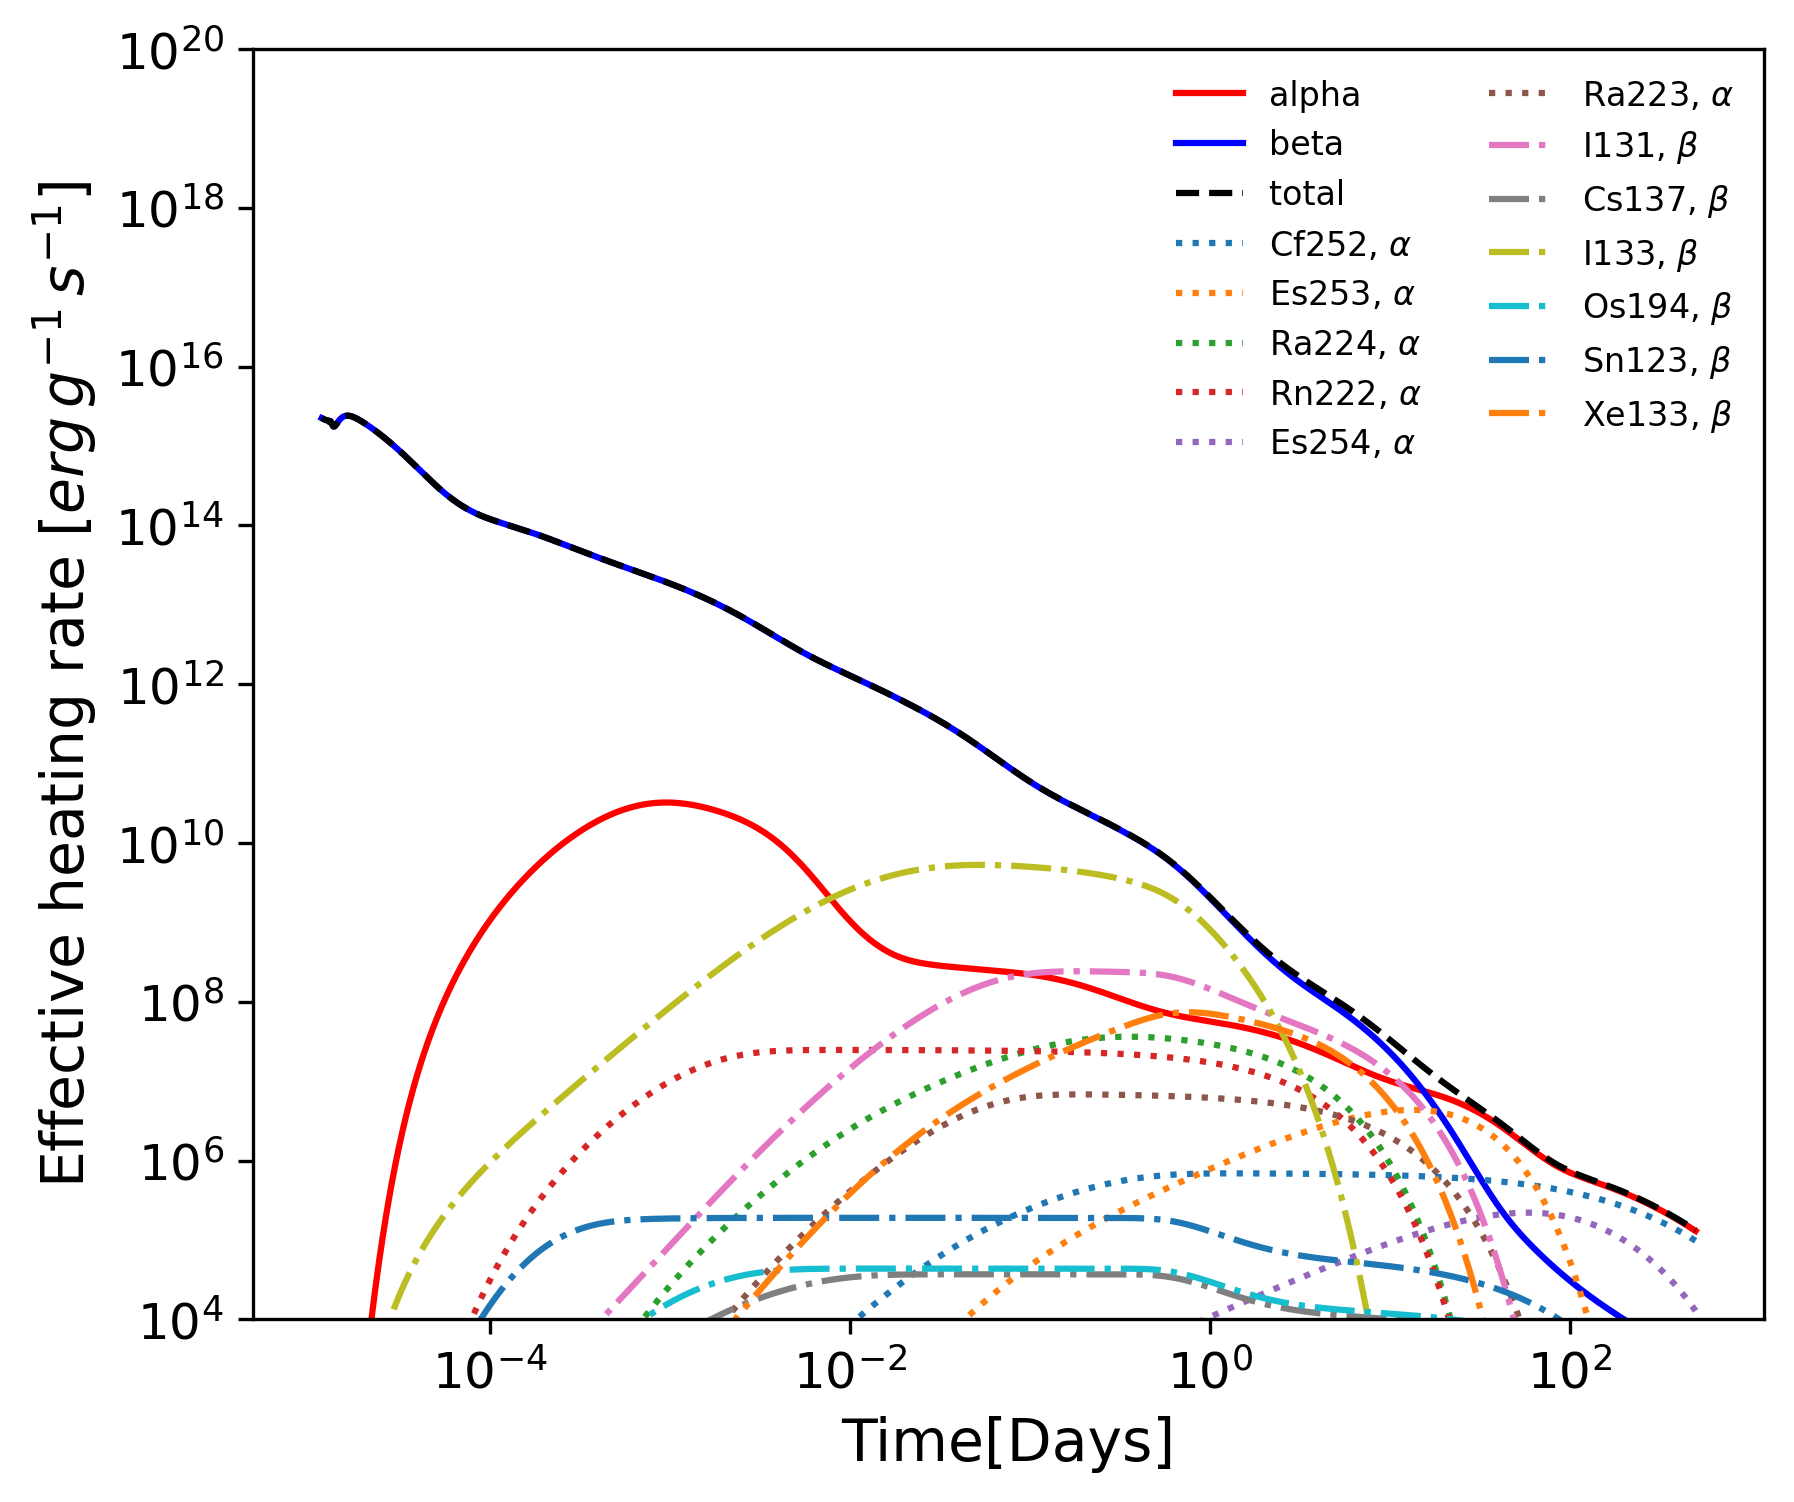

In [9]:
'''Preliminar figures'''
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.figure(figsize=(6.5,5.5), dpi=300)
plt.plot(time_days,e_a_ef,label=r'alpha ',color='red')
plt.plot(time_days,e_b_ef,label=r'beta ',color='blue')
plt.plot(time_days,e_a_ef+e_b_ef,label=r'total ', color='black',linestyle='--')
for i in range(6):
    plt.plot(time_days,e_a_nuclei_sorted[i]*f_alpha,label=f'{nuclei_a_sorted[i]}'+r', $\alpha$',linestyle=':')
for i in range(6):
    plt.plot(time_days,e_b_nuclei_sorted[i]*f_beta,label=f'{nuclei_b_sorted[i]}'+r', $\beta$', linestyle='-.')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Time[Days]')
plt.ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=8)
plt.ylim(1e4,1e20)
#plt.xlim(0.1,500)
#plt.savefig("Run_Exp_weak_rates_viola_seaborg_Approach_II.pdf", bbox_inches="tight")


In [10]:

pd.DataFrame(e_b_ef).to_csv('epsilon_calculations/approach_I/Run_1/Beta_minus.csv')
pd.DataFrame(e_a_ef).to_csv('epsilon_calculations/approach_I/Run_1/Alpha.csv')
for i in range(20):
    pd.DataFrame(e_b_nuclei_sorted[i]*f_beta).to_csv(f'epsilon_calculations/approach_I/Run_1/b_top/{nuclei_b_sorted[i]}_{i}_beta.csv')
    pd.DataFrame(e_a_nuclei_sorted[i]*f_alpha).to_csv(f'epsilon_calculations/approach_I/Run_1/a_top/{nuclei_a_sorted[i]}_{i}_alpha.csv')
    